## Ejemplo boostrapping

Media original: 5.6
Intervalo de confianza del 95%: [3.8 7.4]


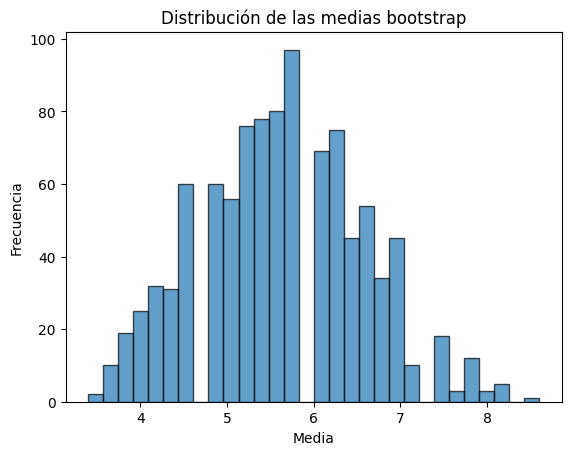

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos originales
data = [4, 7, 9, 3, 5]

# Número de muestras bootstrap
n_iterations = 1000
sample_size = len(data)

# Almacenar las medias de las muestras bootstrap
bootstrap_means = []

# Realizar el bootstrapping
for _ in range(n_iterations):
    sample = np.random.choice(data, size=sample_size, replace=True)
    bootstrap_means.append(np.mean(sample))

# Convertir la lista a un array
bootstrap_means = np.array(bootstrap_means)

# Estimar el intervalo de confianza del 95% (percentil 2.5% y 97.5%)
conf_int = np.percentile(bootstrap_means, [2.5, 97.5])

# Mostrar resultados
print(f"Media original: {np.mean(data)}")
print(f"Intervalo de confianza del 95%: {conf_int}")

# Visualizar la distribución de las medias bootstrap
plt.hist(bootstrap_means, bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribución de las medias bootstrap')
plt.xlabel('Media')
plt.ylabel('Frecuencia')
plt.show()

## Ejemplo Detección anomalias

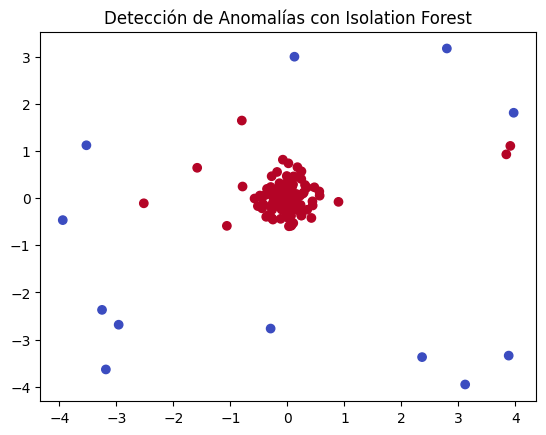

In [2]:
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt

# Generar datos de ejemplo
rng = np.random.RandomState(42)
X_inliers = 0.3 * rng.randn(100, 2)
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.vstack([X_inliers, X_outliers])

# Crear el modelo de detección de anomalías (Isolation Forest)
model = IsolationForest(contamination=0.1, random_state=rng)
model.fit(X)

# Predecir anomalías (-1 para anómalo, 1 para normal)
y_pred = model.predict(X)

# Visualizar los resultados
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='coolwarm')
plt.title("Detección de Anomalías con Isolation Forest")
plt.show()

## Ejemplo autoencoder (imagenes)

In [3]:
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist
import numpy as np

# Cargar los datos MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Aplanar las imágenes (28x28 -> 784)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# Codificador
input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)

# Decodificador
decoded = Dense(784, activation='sigmoid')(encoded)

# Modelo autoencoder
autoencoder = Model(input_img, decoded)

# Modelo de codificación (para ver la representación latente)
encoder = Model(input_img, encoded)

# Compilar el modelo
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenar el autoencoder
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

# Obtener las representaciones latentes de las imágenes
encoded_imgs = encoder.predict(x_test)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3510 - val_loss: 0.1623
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1529 - val_loss: 0.1269
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1233 - val_loss: 0.1091
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1073 - val_loss: 0.0979
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0969 - val_loss: 0.0904
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0902 - val_loss: 0.0852
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0850 - val_loss: 0.0817
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0818 - val_loss: 0.0794
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0795 - val_loss: 0.0775
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0780 - val_loss: 0.0763
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0770 - val_loss: 0.0756
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

## Ejemplo autoencoder deteccion anomalias

Un autoencoder es muy útil para la detección de anomalías porque puede aprender a reconstruir los patrones de datos normales (de entrenamiento). Cuando se le presentan datos anómalos, la red no puede reconstruir bien estos datos, lo que resulta en un alto error de reconstrucción.

A continuación, te muestro un ejemplo práctico en el que utilizamos un autoencoder para detectar anomalías en un conjunto de datos.
Ejemplo: Detección de anomalías con un autoencoder

Vamos a usar el conjunto de datos Fashion MNIST, que contiene imágenes de ropa (p. ej., camisetas, zapatos, pantalones). Las anomalías serán imágenes que no pertenecen a esta categoría, como por ejemplo, imágenes aleatorias.
Paso 1: Cargar el conjunto de datos

Para este ejemplo, cargaremos el conjunto de Fashion MNIST que es una versión de MNIST pero con imágenes de ropa. Lo usaremos para entrenar el autoencoder con imágenes de ropa "normales" y luego veremos cómo el autoencoder detecta imágenes que son "anómalas".

Paso 2: Construcción del Autoencoder

Creamos el modelo autoencoder utilizando Keras. En este caso, el autoencoder tendrá una capa de codificación de 64 neuronas, lo que significa que comprimirá la imagen de 784 dimensiones (28x28 píxeles) a 64 dimensiones. Luego, el decodificador intentará reconstruir la imagen original.

Paso 3: Evaluación del modelo y cálculo del error de reconstrucción

Una vez que el modelo está entrenado, podemos usarlo para detectar anomalías. Calcularemos el error de reconstrucción para cada imagen en el conjunto de prueba. Si el error es alto, eso sugiere que la imagen es anómala.

Paso 4: Definir un umbral para detectar anomalías

Basado en la distribución del error de reconstrucción, podemos definir un umbral a partir del cual consideraremos que una imagen es anómala. Por ejemplo, podríamos decir que cualquier imagen cuyo error de reconstrucción sea mayor que un cierto percentil (por ejemplo, el 95%) será considerada anómala.

Paso 5: Evaluación

El modelo identificará anomalías basándose en el error de reconstrucción. Por ejemplo:

    Imágenes normales (ropa en Fashion MNIST) deberían tener un error de reconstrucción relativamente bajo.

    Imágenes anómalas (como ruido o imágenes que no son de ropa) deberían tener un error de reconstrucción más alto, ya que el autoencoder no ha sido entrenado con datos anómalos y no puede reconstruirlas bien.

Paso 6: Mejorar el Modelo (Opcional)

    Ajuste de hiperparámetros: Puedes experimentar con diferentes tamaños de capas o activaciones.

    Uso de autoencoders convolucionales: Si tienes imágenes más complejas, podrías probar un autoencoder convolucional, que es más efectivo para datos de imágenes.

Resumen del proceso:

    Entrenamiento del autoencoder: Usamos un autoencoder para aprender a reconstruir imágenes de ropa.

    Evaluación del error de reconstrucción: Calculamos el error de reconstrucción en el conjunto de prueba.

    Detección de anomalías: Usamos un umbral de error de reconstrucción para identificar imágenes anómalas (por ejemplo, imágenes de ruido o imágenes de diferentes categorías).

Conclusión:

Los autoencoders son una herramienta poderosa para la detección de anomalías. Al ser entrenados en un conjunto de datos normal, pueden detectar cualquier patrón que se desvíe significativamente de lo aprendido. En este ejemplo, entrenamos un autoencoder con imágenes de ropa y lo utilizamos para detectar anomalías (por ejemplo, imágenes de objetos no relacionados o ruido).

Si quieres realizar experimentos más complejos o usar otro tipo de datos, ¡déjame saber y te puedo ayudar!

In [4]:
from keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

# Cargar Fashion MNIST
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Preprocesamiento
x_train = x_train.astype('float32') / 255.  # Normalizar a [0, 1]
x_test = x_test.astype('float32') / 255.

# Aplanar las imágenes (28x28 -> 784)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [5]:
from keras.models import Model
from keras.layers import Input, Dense

# Codificador
input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)

# Decodificador
decoded = Dense(784, activation='sigmoid')(encoded)

# Modelo autoencoder
autoencoder = Model(input_img, decoded)

# Compilar el modelo
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenar el autoencoder
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4731 - val_loss: 0.3256
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3170 - val_loss: 0.3057
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3007 - val_loss: 0.2948
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2908 - val_loss: 0.2888
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2854 - val_loss: 0.2849
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2816 - val_loss: 0.2826
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2805 - val_loss: 0.2808
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2783 - val_loss: 0.2797
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2768 - val_loss: 0.2785
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2759 - val_loss: 0.2777
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2754 - val_loss: 0.2769
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step


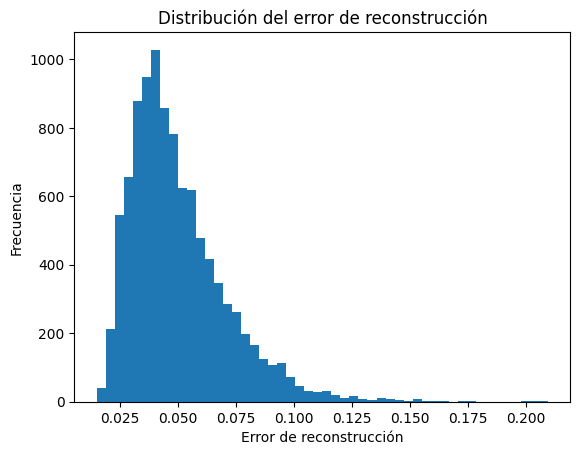

In [6]:
# Obtener las reconstrucciones
decoded_imgs = autoencoder.predict(x_test)

# Calcular el error de reconstrucción
reconstruction_error = np.mean(np.abs(x_test - decoded_imgs), axis=1)

# Visualizar algunos errores de reconstrucción
plt.hist(reconstruction_error, bins=50)
plt.title('Distribución del error de reconstrucción')
plt.xlabel('Error de reconstrucción')
plt.ylabel('Frecuencia')
plt.show()

Número de anomalías detectadas: 500


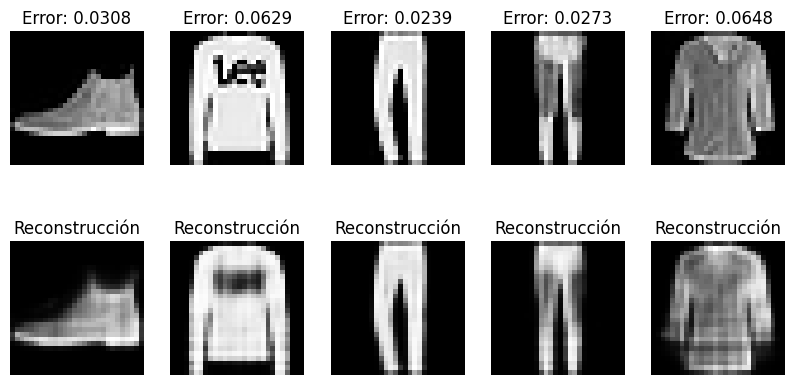

In [7]:
# Definir el umbral de anomalía
threshold = np.percentile(reconstruction_error, 95)

# Detectar anomalías
anomalies = reconstruction_error > threshold

# Mostrar algunos ejemplos
print(f"Número de anomalías detectadas: {np.sum(anomalies)}")

# Visualizar algunas imágenes con su error de reconstrucción
plt.figure(figsize=(10, 5))
for i in range(5):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Error: {reconstruction_error[i]:.4f}')
    ax.axis('off')
    
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.set_title('Reconstrucción')
    ax.axis('off')

plt.show()


## Autoencoder: detección anomlias en multivariable
La detección de anomalías en un proceso multivariable mediante un autoencoder es una técnica muy poderosa, especialmente en situaciones donde las relaciones entre diferentes variables son complejas, como en el monitoreo de sistemas de manufactura, procesos industriales, o cualquier tipo de datos multivariables (es decir, más de una variable o característica).

A continuación, te proporcionaré un ejemplo de cómo usar un autoencoder para detectar anomalías en datos multivariables, por ejemplo, en un proceso industrial, utilizando un conjunto de datos ficticio.
Ejemplo de Detección de Anomalías con Autoencoder en Datos Multivariables

Supongamos que tenemos un conjunto de datos con varias variables de proceso (por ejemplo, temperatura, presión, velocidad, etc.). Usaremos un autoencoder para aprender las relaciones entre estas variables y luego detectar anomalías basándonos en el error de reconstrucción.
Paso 1: Crear un conjunto de datos multivariable simulado

En este ejemplo, vamos a generar un conjunto de datos ficticios con algunas características multivariables, en el que introduciremos anomalías de forma manual.

Primeros 5 puntos de datos normalizados:
[[ 0.12781781 -0.16696248  0.68190886  1.593328   -0.24480338 -0.19766907
   1.53476209  0.73942652 -0.45254674  0.53392184]
 [-0.39235222 -0.48941772  0.26911296 -1.90271371 -1.71768893 -0.51426231
  -0.98004071  0.29962931 -0.89716418 -1.53513054]
 [ 0.65275691 -0.25313554  0.09163944 -1.40568975 -0.55131212  0.13523762
  -1.11408602  0.35926433 -0.58552583 -0.34906287]
 [-0.46727292  1.79312477  0.00920217 -1.03227248  0.7992218  -1.14962435
   0.20524834 -1.90710138 -1.32313948  0.16802988]
 [ 0.25879187  0.13793274 -0.09472884 -0.26251353 -1.47424814 -0.66626991
  -0.44430331  1.0205547   0.37179583 -1.90635441]]
Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2752 - val_loss: 1.1320
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 1.2278 - val_loss: 1.1087
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - loss: 1.2043 - val_loss: 1.0860
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step - loss: 1.1987 - val_

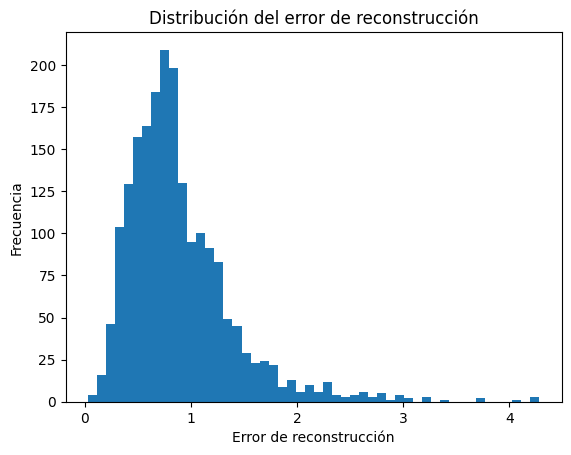

Total de anomalías detectadas: 100


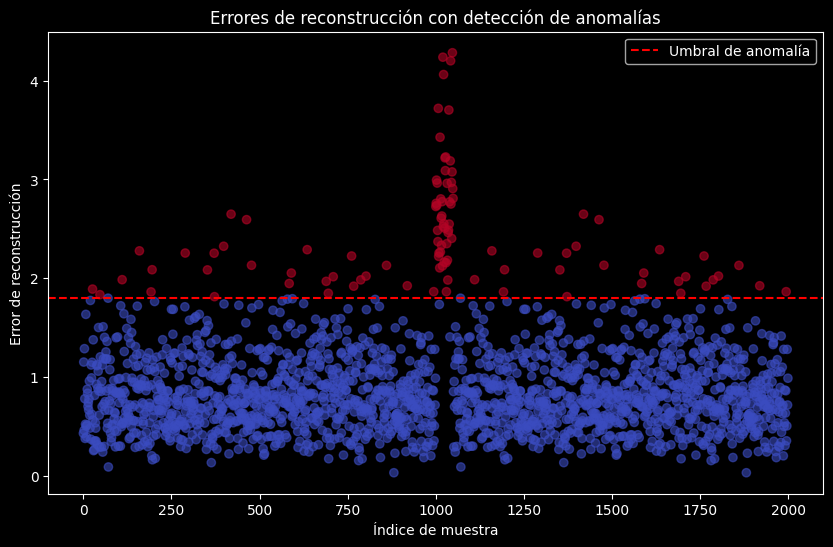

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from keras.models import Model
from keras.layers import Input, Dense
from sklearn.metrics import confusion_matrix, classification_report

# Generar datos de proceso multivariable (simulados)
np.random.seed(42)
n_samples = 1000

# Datos normales (simulados)
X_normal = np.random.normal(loc=0, scale=1, size=(n_samples, 10))  # 3 variables

# Introducir algunas anomalías (valores mucho más altos en una de las variables)
n_anomalies = 50
X_anomalous = np.copy(X_normal)
X_anomalous[:n_anomalies, 0] += 10  # Anomalía en la primera variable

# Combinar datos normales y anómalos
X = np.vstack([X_normal, X_anomalous])

# Etiquetas (0: normal, 1: anómalo)
y = np.concatenate([np.zeros(n_samples-n_anomalies), np.ones(n_anomalies)])

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualizar los primeros 5 puntos de datos
print("Primeros 5 puntos de datos normalizados:")
print(X_scaled[:5])


# Construir el autoencoder
input_dim = X_scaled.shape[1]  # 3 variables (3 dimensiones)
encoding_dim = 2  # Dimensión latente reducida (puedes ajustar este valor)

# Codificador
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decodificador
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Modelo autoencoder
autoencoder = Model(input_layer, decoded)

# Compilar el modelo
autoencoder.compile(optimizer='adam', loss='mse')

# Entrenar el autoencoder
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# Calcular las reconstrucciones
reconstructed = autoencoder.predict(X_scaled)

# Calcular el error de reconstrucción (usamos el MSE)
reconstruction_error = np.mean(np.square(X_scaled - reconstructed), axis=1)

# Visualizar los errores de reconstrucción
plt.hist(reconstruction_error, bins=50)
plt.title('Distribución del error de reconstrucción')
plt.xlabel('Error de reconstrucción')
plt.ylabel('Frecuencia')
plt.show()


# Definir el umbral de anomalía (usando el percentil 95 del error de reconstrucción)
threshold = np.percentile(reconstruction_error, 95)

# Detectar anomalías (error de reconstrucción > umbral)
anomalies = reconstruction_error > threshold

# Mostrar los resultados
print(f"Total de anomalías detectadas: {np.sum(anomalies)}")

plt.style.use('dark_background')
                  
# Visualizar algunas anomalías detectadas
plt.figure(figsize=(10, 6))
plt.scatter(range(len(X_scaled)), reconstruction_error, c=anomalies, cmap='coolwarm', alpha=0.6)
plt.axhline(threshold, color='r', linestyle='--', label='Umbral de anomalía')
plt.title('Errores de reconstrucción con detección de anomalías')
plt.xlabel('Índice de muestra')
plt.ylabel('Error de reconstrucción')
plt.legend()
plt.show()



# Comparar las anomalías detectadas con las etiquetas reales
#print("Matriz de confusión:")
#print(confusion_matrix(y, anomalies))

#print("\nReporte de clasificación:")
#print(classification_report(y, anomalies))


## Autoencoder: detección anomlias en multivariable secuenciales

Detectar anomalías en datos secuenciales que contienen tanto variables numéricas como categóricas utilizando un autoencoder es una tarea interesante y puede ser bastante útil en varios contextos, como la detección de fraudes, monitoreo de sistemas, o procesos industriales.

Los autoencoders generalmente se utilizan con datos numéricos, pero se puede extender este enfoque para trabajar con datos mixtos (numéricos y categóricos) en secuencias. La idea es preprocesar adecuadamente los datos categóricos y luego usar un autoencoder para modelar tanto las características numéricas como las transformadas categóricas.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Generar datos ficticios (simulación de un proceso)
np.random.seed(42)
n_samples = 1000
sequence_length = 10

# Generar variables numéricas (simulando variables como temperatura, presión)
X_numeric = np.random.normal(loc=0, scale=1, size=(n_samples, sequence_length, 2))  # 2 variables numéricas

# Generar variables categóricas (simulando variables como estado del sistema, modo de operación)
X_categorical = np.random.choice(['A', 'B', 'C'], size=(n_samples, sequence_length, 1))

# Combinar los datos numéricos y categóricos
X_raw = np.concatenate([X_numeric, X_categorical], axis=2)

# Visualizar los primeros datos
print("Primeras muestras del conjunto de datos:")
print(X_raw[:2])

# Preprocesar: Escalar las variables numéricas
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_raw[:, :, :2].reshape(-1, 2)).reshape(n_samples, sequence_length, 2)

# Preprocesar: Codificar las variables categóricas (OneHotEncoding)
encoder = OneHotEncoder()
X_categorical_encoded_ = encoder.fit_transform(X_raw[:, :, 2].reshape(-1, 1))
X_categorical_encoded = X_categorical_encoded_.reshape(n_samples, -1) # -1)

# Asegurémonos de que las variables codificadas tengan la forma correcta (n_samples, sequence_length, n_features_categóricos)
print("Forma de X_categorical_encoded:", X_categorical_encoded.shape)

# Combinar las variables numéricas escaladas y las categóricas codificadas
X_processed = np.concatenate([X_numeric_scaled, X_categorical_encoded], axis=2)

# Mostrar una muestra preprocesada
print("Muestra preprocesada:")
print(X_processed[:1])

from keras.models import Model
from keras.layers import Input, LSTM, Dense, TimeDistributed

# Definir las dimensiones de entrada
input_dim = X_processed.shape[2]  # Número total de características (numéricas + categóricas)
sequence_length = X_processed.shape[1]  # Longitud de la secuencia (en este caso, 10)

# Construcción del modelo autoencoder
input_layer = Input(shape=(sequence_length, input_dim))

# Codificador (Encoder)
encoded = LSTM(64, activation='relu', return_sequences=False)(input_layer)
encoded = Dense(32, activation='relu')(encoded)

# Decodificador (Decoder)
decoded = Dense(64, activation='relu')(encoded)
decoded = RepeatVector(sequence_length)(decoded)
decoded = LSTM(input_dim, activation='sigmoid', return_sequences=True)(decoded)

# Modelo Autoencoder
autoencoder = Model(input_layer, decoded)

# Compilar el modelo
autoencoder.compile(optimizer='adam', loss='mse')

# Resumen del modelo
autoencoder.summary()

# Dividir los datos en entrenamiento y prueba
X_train, X_test = train_test_split(X_processed, test_size=0.2, random_state=42)

# Entrenar el autoencoder
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, validation_data=(X_test, X_test), verbose=1)

# Obtener las reconstrucciones
reconstructed = autoencoder.predict(X_test)

# Calcular el error de reconstrucción (usamos el error cuadrático medio)
reconstruction_error = np.mean(np.square(X_test - reconstructed), axis=(1, 2))

# Visualizar el error de reconstrucción
plt.hist(reconstruction_error, bins=50)
plt.title('Distribución del error de reconstrucción')
plt.xlabel('Error de reconstrucción')
plt.ylabel('Frecuencia')
plt.show()

# Definir un umbral para detectar anomalías (usamos el percentil 95 del error de reconstrucción)
threshold = np.percentile(reconstruction_error, 95)

# Detectar anomalías
anomalies = reconstruction_error > threshold

# Mostrar las anomalías detectadas
print(f"Total de anomalías detectadas: {np.sum(anomalies)}")

# Suponiendo que tenemos etiquetas para las anomalías (esto es solo un ejemplo)
y_test = np.zeros(len(X_test))  # Etiquetas simuladas de no anomalía (0) para todas las muestras



Primeras muestras del conjunto de datos:
[[['0.4967141530112327' '-0.13826430117118466' 'A']
  ['0.6476885381006925' '1.5230298564080254' 'B']
  ['-0.23415337472333597' '-0.23413695694918055' 'A']
  ['1.5792128155073915' '0.7674347291529088' 'C']
  ['-0.4694743859349521' '0.5425600435859647' 'C']
  ['-0.46341769281246226' '-0.46572975357025687' 'C']
  ['0.24196227156603412' '-1.913280244657798' 'A']
  ['-1.7249178325130328' '-0.5622875292409727' 'B']
  ['-1.0128311203344238' '0.3142473325952739' 'B']
  ['-0.9080240755212109' '-1.4123037013352915' 'B']]

 [['1.465648768921554' '-0.22577630048653566' 'A']
  ['0.06752820468792384' '-1.4247481862134568' 'A']
  ['-0.5443827245251827' '0.11092258970986608' 'C']
  ['-1.1509935774223028' '0.37569801834567196' 'B']
  ['-0.600638689918805' '-0.2916937497932768' 'A']
  ['-0.6017066122293969' '1.8522781845089378' 'B']
  ['-0.013497224737933921' '-1.0577109289559004' 'B']
  ['0.822544912103189' '-1.2208436499710222' 'A']
  ['0.2088635950047554' '-1

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 3 dimension(s) and the array at index 1 has 0 dimension(s)

## Ejemplo Isolation forest

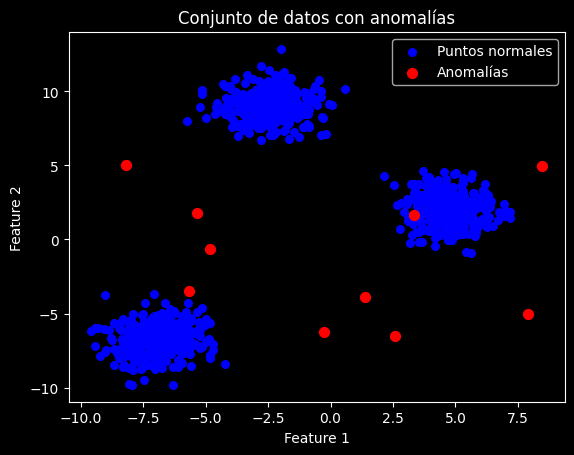

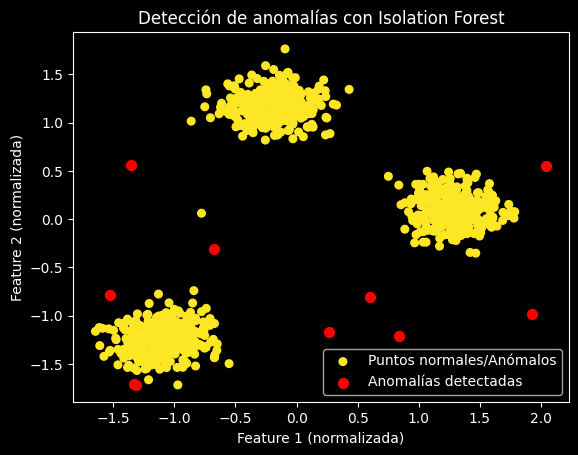

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# Generar un conjunto de datos multivariante con dos características
X, y = make_blobs(n_samples=1000, centers=3, cluster_std=1.0, random_state=42)

# Introducir algunos puntos anómalos (outliers) al conjunto de datos
X[950:960] = np.random.uniform(low=-10, high=10, size=(10, 2))  # Añadir outliers aleatorios

# Visualización del conjunto de datos con outliers
plt.scatter(X[:, 0], X[:, 1], s=30, color='blue', label='Puntos normales')
plt.scatter(X[950:960, 0], X[950:960, 1], s=50, color='red', label='Anomalías')
plt.title("Conjunto de datos con anomalías")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# Normalizar los datos para mejorar la precisión del modelo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar Isolation Forest
model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
y_pred = model.fit_predict(X_scaled)

# El resultado de `fit_predict` es -1 para anomalías y 1 para puntos normales
# Convertimos -1 a 0 para representar las anomalías y 1 para los puntos normales
y_pred = np.where(y_pred == -1, 0, 1)

# Visualizar los resultados
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, s=30, label='Puntos normales/Anómalos')
plt.scatter(X_scaled[y_pred == 0, 0], X_scaled[y_pred == 0, 1], color='red', s=50, label='Anomalías detectadas')
plt.title("Detección de anomalías con Isolation Forest")
plt.xlabel("Feature 1 (normalizada)")
plt.ylabel("Feature 2 (normalizada)")
plt.legend()
plt.show()

## Ejemplo de LSTM para detección de anomalias

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras import regularizers

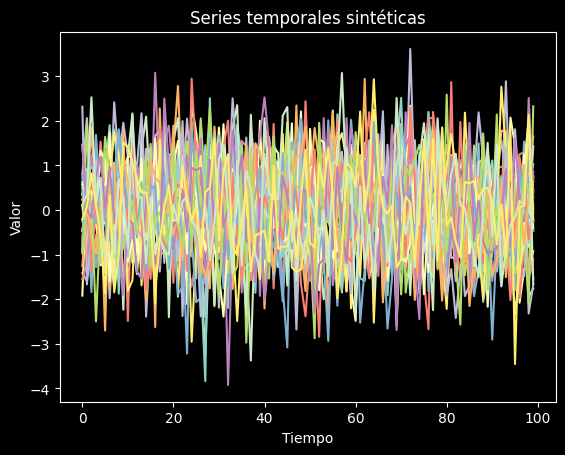

/Users/joseangelvelasco/Documents/PycharmProjects/HI-DataScience-Tests/.env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 30, 10)         │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,850 (77.54 KB)

 Trainable params: 19,850 (77.54 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Simulación de datos de series temporales multivariantes
np.random.seed(42)
n_samples = 1000
sequence_length = 30
n_variables = 10
# Generar datos sintéticos (3 variables)
X = np.random.normal(loc=0, scale=1, size=(n_samples, sequence_length, n_variables))

# Introducir anomalías (outliers)
X[950:960] = np.random.uniform(low=-10, high=10, size=(10, sequence_length, n_variables))  # Anomalías aleatorias

# Visualizar las primeras secuencias de datos
plt.plot(X[:100, :, 0])  # Graficar la primera variable (por ejemplo, Temperatura)
plt.title('Series temporales sintéticas')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.show()

scaler = StandardScaler()
X_scaled = X.reshape(-1, n_variables)  # Convertir a 2D para normalización
X_scaled = scaler.fit_transform(X_scaled)
X_scaled = X_scaled.reshape(n_samples, sequence_length, n_variables)  # Volver a darle la forma de serie temporal

# Dividir los datos en entrenamiento y prueba
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

# Crear el modelo LSTM
model = Sequential()

# Capa LSTM con return_sequences=True para que devuelva la secuencia completa
model.add(LSTM(64, activation='relu', input_shape=(sequence_length, n_variables), return_sequences=True))
model.add(Dropout(0.2))  # Regularización con Dropout

# Capa de salida
model.add(Dense(n_variables, activation='linear', kernel_regularizer=regularizers.l2(0.01)))  # Mismas características que la entrada

# Compilamos el modelo
model.compile(optimizer='adam', loss='mse')

# Resumen del modelo
model.summary()




In [39]:
X_train.shape

(800, 30, 10)

In [40]:
# Entrenar el modelo
history = model.fit(X_train, X_train, epochs=50, batch_size=32, validation_data=(X_test, X_test), verbose=1)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.1059 - val_loss: 0.8960
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0563 - val_loss: 0.8740
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9860 - val_loss: 0.8451
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9355 - val_loss: 0.7847
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8940 - val_loss: 0.7299
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7878 - val_loss: 0.6003
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7248 - val_loss: 0.5225
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6430 - val_loss: 0.4454
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5451 - val_loss: 0.3782
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5042 - val_loss: 0.3211
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5037 - val_loss: 0.2871
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4236 - val_l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


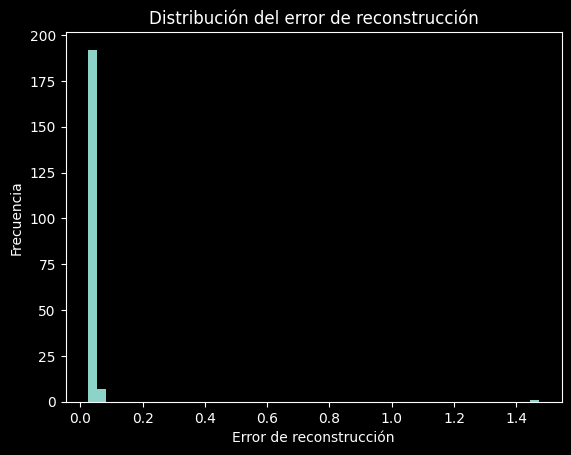

Total de anomalías detectadas: 10


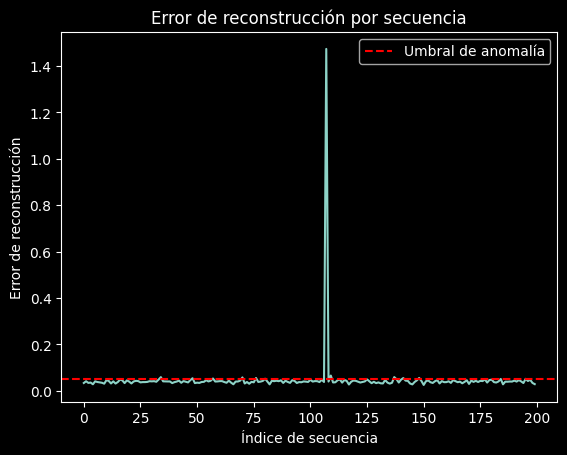

In [41]:
# Hacer predicciones
X_pred = model.predict(X_test)

# Calcular el error cuadrático medio de reconstrucción por secuencia
reconstruction_error = np.mean(np.square(X_test - X_pred), axis=(1, 2))

# Visualizar la distribución del error de reconstrucción
plt.hist(reconstruction_error, bins=50)
plt.title('Distribución del error de reconstrucción')
plt.xlabel('Error de reconstrucción')
plt.ylabel('Frecuencia')
plt.show()

# Definir un umbral para anomalías basado en el percentil 95 del error de reconstrucción
threshold = np.percentile(reconstruction_error, 95)

# Detectar anomalías
anomalies = reconstruction_error > threshold

# Mostrar las anomalías detectadas
print(f"Total de anomalías detectadas: {np.sum(anomalies)}")

# Visualizar las anomalías
plt.plot(reconstruction_error)
plt.axhline(y=threshold, color='r', linestyle='--', label='Umbral de anomalía')
plt.title('Error de reconstrucción por secuencia')
plt.xlabel('Índice de secuencia')
plt.ylabel('Error de reconstrucción')
plt.legend()
plt.show()


## Ejemplo LSTM para detección anomalias 

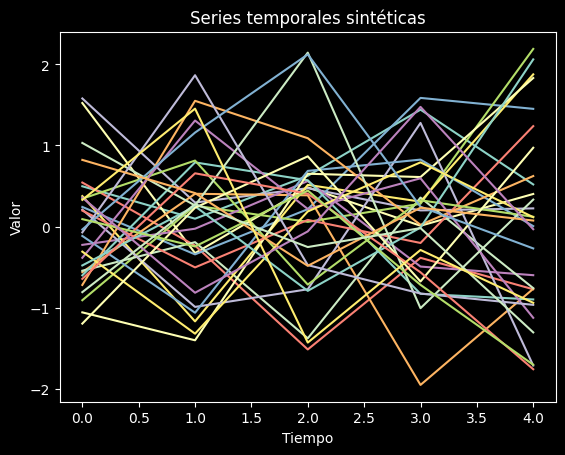

Epoch 1/50


/Users/joseangelvelasco/Documents/PycharmProjects/HI-DataScience-Tests/.env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0511 - val_loss: 0.7946
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8394 - val_loss: 0.8012
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0170 - val_loss: 0.7828
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8681 - val_loss: 0.7568
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8413 - val_loss: 0.7147
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8272 - val_loss: 0.7005
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7083 - val_loss: 0.6586
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6864 - val_loss: 0.5972
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6706 - val_loss: 0.4976
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6023 - val_loss: 0.4237
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4997 - val_loss: 0.3718
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4719 - val_loss: 0.3193

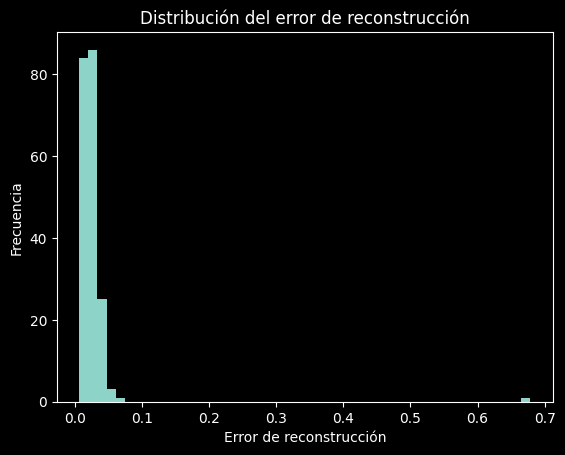

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras import regularizers

# Simulación de datos de series temporales multivariantes
np.random.seed(42)
n_samples = 1000
sequence_length = 30

# Generar datos sintéticos (3 variables)
X = np.random.normal(loc=0, scale=1, size=(n_samples, sequence_length, 3))

# Introducir anomalías (outliers)
X[950:960] = np.random.uniform(low=-10, high=10, size=(10, sequence_length, 3))  # Anomalías aleatorias

# Visualizar las primeras secuencias de datos
plt.plot(X[:5, :, 0])  # Graficar la primera variable (por ejemplo, Temperatura)
plt.title('Series temporales sintéticas')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.show()

# Normalización de los datos
scaler = StandardScaler()
X_scaled = X.reshape(-1, 3)  # Convertir a 2D para normalización
X_scaled = scaler.fit_transform(X_scaled)
X_scaled = X_scaled.reshape(n_samples, sequence_length, 3)  # Volver a darle la forma de serie temporal

# Dividir los datos en entrenamiento y prueba
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

# Crear el modelo LSTM
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(sequence_length, 3), return_sequences=True))
model.add(Dropout(0.2))  # Regularización con Dropout
model.add(Dense(3, activation='linear', kernel_regularizer=regularizers.l2(0.01)))  # Mismas características que la entrada

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
history = model.fit(X_train, X_train, epochs=50, batch_size=32, validation_data=(X_test, X_test), verbose=1)

# Hacer predicciones
X_pred = model.predict(X_test)

# Calcular el error cuadrático medio de reconstrucción por secuencia
reconstruction_error = np.mean(np.square(X_test - X_pred), axis=(1, 2))

# Visualizar la distribución del error de reconstrucción
plt.hist(reconstruction_error, bins=50)
plt.title('Distribución del error de reconstrucción')
plt.xlabel('Error de reconstrucción')
plt.ylabel('Frecuencia')
plt.show()

# Definir un umbral para anomalías basado en el percentil 95 del error de reconstrucción
threshold = np.percentile(reconstruction_error, 95)

# Detectar anomalías
anomalies = reconstruction_error > threshold



Total de anomalías detectadas: 10


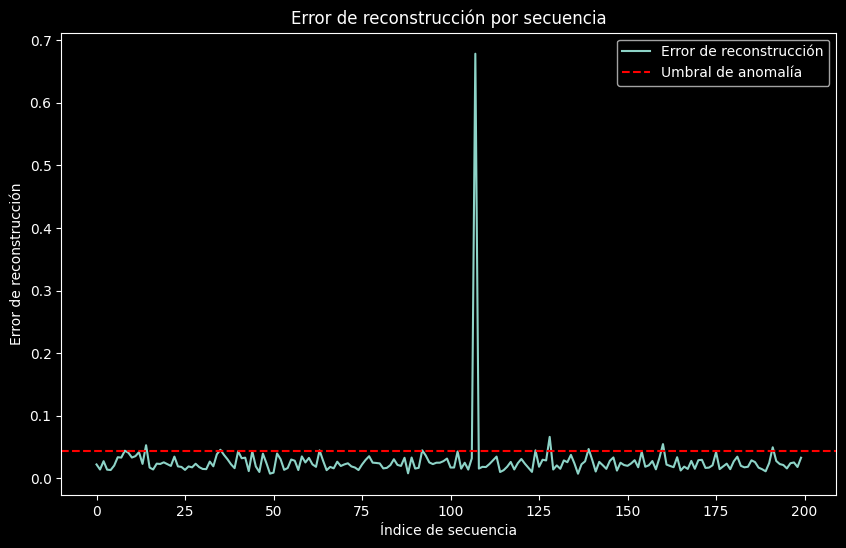

/var/folders/j0/5dg8hqb56g74gtnfq8brkc9h0000gn/T/ipykernel_78520/3450849290.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


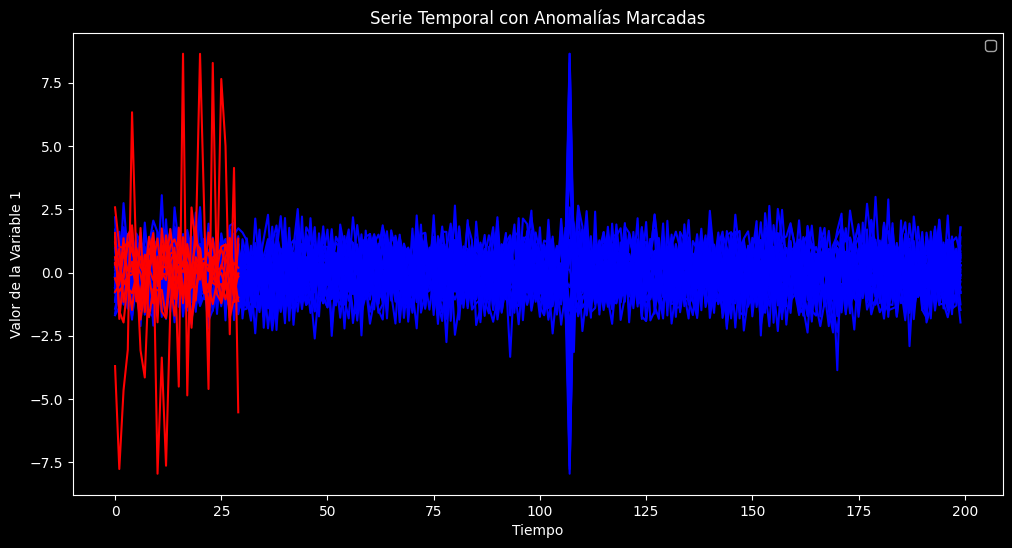

In [48]:
# Mostrar las anomalías detectadas
print(f"Total de anomalías detectadas: {np.sum(anomalies)}")

# Visualizar el error de reconstrucción y marcar las anomalías en rojo
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, label='Error de reconstrucción')
plt.axhline(y=threshold, color='r', linestyle='--', label='Umbral de anomalía')
plt.title('Error de reconstrucción por secuencia')
plt.xlabel('Índice de secuencia')
plt.ylabel('Error de reconstrucción')
plt.legend()
plt.show()

# Mostrar la serie temporal y marcar las anomalías
plt.figure(figsize=(12, 6))

# Graficar las secuencias originales (tomando solo una variable, por ejemplo la primera)
plt.plot(X_test[:, :, 0], color='blue')

# Marcar las anomalías en rojo
for i in range(len(anomalies)):
    if anomalies[i]:
        plt.plot(np.arange(sequence_length), X_test[i, :, 0], color='red', label=f'Anomalía {i+1}' if i == 0 else "")

plt.title('Serie Temporal con Anomalías Marcadas')
plt.xlabel('Tiempo')
plt.ylabel('Valor de la Variable 1')
plt.legend(loc='upper right')
plt.show()

## Ejemplo LSTm para forecasting

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout


In [60]:
# Generar datos sintéticos de series temporales de clima (Ejemplo con 3 variables)
np.random.seed(42)
n_samples = 1000
sequence_length = 30  # longitud de la secuencia
n_features = 3  # Temperatura, Humedad y Presión

# Generar series temporales sintéticas para 3 variables
X = np.random.normal(loc=0, scale=1, size=(n_samples, n_features))

# Crear un DataFrame
df = pd.DataFrame(X, columns=['Temperature', 'Humidity', 'Pressure'])

# Visualizar las primeras filas del conjunto de datos
df.head()


,Temperature,Humidity,Pressure
0,0.496714,-0.138264,0.647689
1,1.523030,-0.234153,-0.234137
2,1.579213,0.767435,-0.469474
3,0.542560,-0.463418,-0.465730
4,0.241962,-1.913280,-1.724918


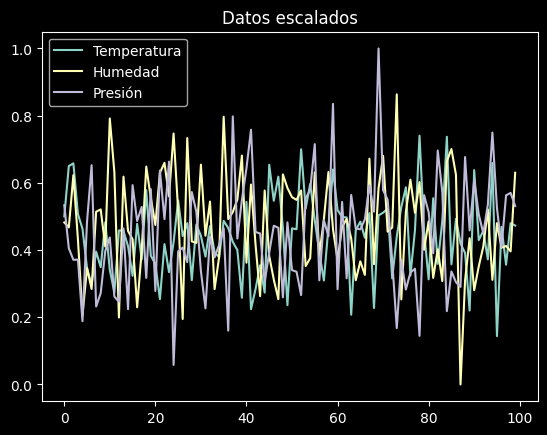

In [61]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# Visualizar los datos escalados
plt.plot(scaled_data[:100, 0], label='Temperatura')
plt.plot(scaled_data[:100, 1], label='Humedad')
plt.plot(scaled_data[:100, 2], label='Presión')
plt.legend()
plt.title('Datos escalados')
plt.show()

In [62]:
# Función para crear secuencias con formato correcto
def create_sequences(data, sequence_length, prediction_length):
    X = []
    y = []
    
    for i in range(sequence_length, len(data) - prediction_length):
        X.append(data[i - sequence_length:i, :])  # Secuencias de entrada
        y.append(data[i:i + prediction_length, :])  # Predicción de los siguientes `prediction_length` periodos
    
    return np.array(X), np.array(y)

# Crear secuencias de entrada y etiquetas para predicción de 100 periodos
sequence_length = 30
prediction_length = 100
X, y = create_sequences(scaled_data, sequence_length, prediction_length)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [63]:
# Crear el modelo LSTM
model = Sequential()

# Capa LSTM
model.add(LSTM(units=64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Capa de salida: tenemos que predecir 100 periodos (100 * 3)
model.add(Dense(prediction_length * y_train.shape[2], activation='linear'))

# Cambiar la salida a la forma adecuada para hacer predicciones por cada característica
model.add(Dense(prediction_length * y_train.shape[2]))

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Resumen del modelo
model.summary()

/Users/joseangelvelasco/Documents/PycharmProjects/HI-DataScience-Tests/.env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 300)            │        19,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 300)            │        90,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,208 (496.91 KB)

 Trainable params: 127,208 (496.91 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50


ValueError: Dimensions must be equal, but are 3 and 300 for '{{node compile_loss/mean_squared_error/sub}} = Sub[T=DT_FLOAT](data_1, sequential_13_1/dense_24_1/Add)' with input shapes: [?,100,3], [?,300].

In [56]:
# Hacer predicciones recursivas
def recursive_forecast(model, input_sequence, n_periods):
    predictions = []
    current_input = input_sequence
    
    for _ in range(n_periods):
        # Realizar la predicción
        pred = model.predict(current_input[np.newaxis, :, :])[0]
        predictions.append(pred)
        
        # Actualizar la entrada para la siguiente predicción (agregar la predicción y descartar el primer valor)
        current_input = np.roll(current_input, -1, axis=0)
        current_input[-1, :] = pred  # Reemplazar el último valor con la predicción

    return np.array(predictions)

# Predecir los próximos 100 períodos
n_periods = 100
input_sequence = X_test[0]  # Tomamos la primera secuencia de prueba
predictions = recursive_forecast(model, input_sequence, n_periods)

# Desescalar las predicciones
predictions_rescaled = scaler.inverse_transform(predictions)

# Visualizar las predicciones
plt.figure(figsize=(12, 6))
plt.plot(df.index[-30:], df['Temperature'].iloc[-30:], label="Valores reales (últimos 30 períodos)", color='blue')
plt.plot(range(30, 30 + n_periods), predictions_rescaled[:, 0], label="Predicción de Temperatura (100 períodos)", color='red')
plt.title("Pronóstico de Temperatura (100 períodos)")
plt.xlabel("Períodos")
plt.ylabel("Temperatura")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


ValueError: could not broadcast input array from shape (300,) into shape (3,)

## Ejemplo SVDD deteccion anomalias

La detección de anomalías con Deep SVDD (Support Vector Data Description) es un enfoque basado en el uso de redes neuronales profundas para aprender una representación de los datos en un espacio de características y luego usar el principio del Support Vector Machine (SVM) para detectar las observaciones que se desvían significativamente de esta descripción del conjunto de datos "normal".
¿Cómo funciona Deep SVDD?

    Red Neuronal: Una red neuronal profunda aprende una representación de los datos.

    Máquinas de Vectores de Soporte (SVM): Al utilizar una red neuronal para proyectar los datos a un espacio de características, Deep SVDD intenta encontrar una esfera de mínimo volumen que contenga la mayor parte de los datos de entrenamiento (datos "normales").

    Detección de anomalías: Después de entrenar el modelo, las instancias que se encuentran fuera de la esfera (es decir, con una gran distancia al centro de la esfera) se consideran anomalías.

Implementación con Keras y TensorFlow

Vamos a implementar un ejemplo de detección de anomalías utilizando Deep SVDD para un conjunto de datos sintético. Usaremos la red neuronal para aprender una representación de los datos y luego aplicar un umbral basado en la distancia a la esfera para detectar las anomalías.


Epoch 1/100


/Users/joseangelvelasco/Documents/PycharmProjects/HI-DataScience-Tests/.env/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - loss: 0.9304
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - loss: 0.7613
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - loss: 0.6242
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step - loss: 0.5774
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step - loss: 0.4946
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step - loss: 0.4771
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - loss: 0.3898
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 0.2975
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - loss: 0.2740
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - loss: 0.2363
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - loss: 0.2020
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - loss: 0.1419
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - loss: 0.0770
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - loss: 0.0152
Epoch 15/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step -

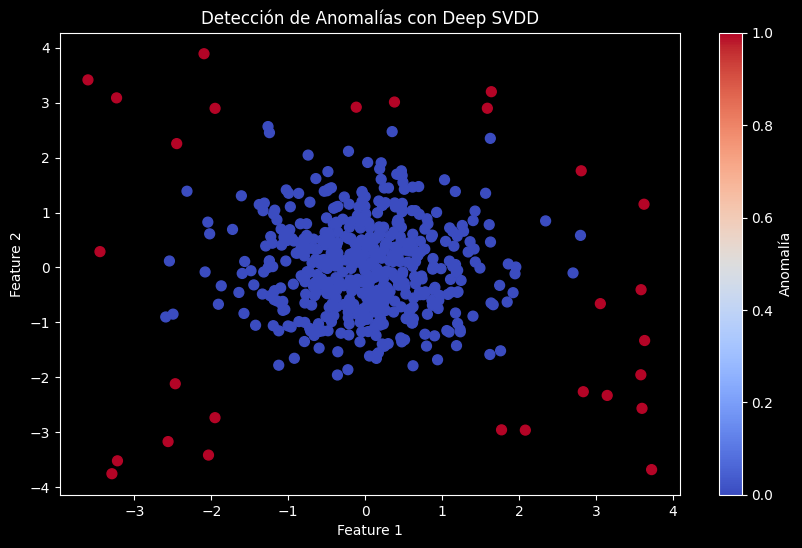

Anomalías detectadas: 28


In [65]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generamos un conjunto de datos sintético 2D
np.random.seed(42)

# Generar datos "normales" (ej. de distribución normal)
X_normal = np.random.normal(loc=0, scale=1, size=(500, 2))

# Generar datos "anómalos" (ej. puntos fuera de la distribución normal)
X_anomalous = np.random.uniform(low=-5, high=5, size=(50, 2))

# Concatenamos los datos normales y anómalos
X = np.concatenate([X_normal, X_anomalous], axis=0)

# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en entrenamiento (solo datos normales) y prueba (normales + anómalos)
X_train = X_normal
X_test = X_scaled

# Definimos el modelo de red neuronal (autoencoder)
def build_model(input_shape):
    model = keras.Sequential([
        layers.InputLayer(input_shape=input_shape),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(4, activation='relu'),
        layers.Dense(2, activation='linear')  # Proyección al espacio latente
    ])
    return model

# Crear el modelo
model = build_model(X_train.shape[1:])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo usando solo los datos normales
model.fit(X_train, X_train, epochs=100, batch_size=32, verbose=1)

# Obtener las representaciones en el espacio latente
latent_representation = model.predict(X_test)

# Calcular la distancia Euclidiana al centro del espacio latente
distances = np.linalg.norm(latent_representation, axis=1)

# Definir un umbral para anomalías basado en el percentil 95 de las distancias
threshold = np.percentile(distances, 95)

# Detectar anomalías: cualquier punto con una distancia mayor al umbral es una anomalía
anomalies = distances > threshold

# Visualizar los resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=anomalies, cmap='coolwarm', s=50, marker='o')
plt.title("Detección de Anomalías con Deep SVDD")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Anomalía')
plt.show()

# Mostrar el número de anomalías detectadas
print(f"Anomalías detectadas: {np.sum(anomalies)}")

## Ejeplo de BNNs en deteccion anomalias

El uso de Redes Neuronales Bayesianas (Bayesian Neural Networks, BNNs) para detección de anomalías se basa en la capacidad de estos modelos para modelar la incertidumbre y proporcionar distribuciones de probabilidad sobre las predicciones, en lugar de simplemente dar una salida determinística. Esto es especialmente útil para la detección de anomalías, ya que nos permite identificar cuándo una predicción está fuera de lo común, es decir, cuándo un dato es muy incierto y por lo tanto es más probable que sea una anomalía.
Conceptos clave

    Redes Neuronales Bayesianas: En lugar de tener un solo conjunto de pesos fijos como en una red neuronal clásica, una red neuronal bayesiana modela los pesos como distribuciones de probabilidad. Esto permite que el modelo capture la incertidumbre sobre los pesos y predicciones, lo que es crucial para la detección de anomalías.

    Detección de Anomalías: Dado que las BNNs modelan incertidumbre, se pueden utilizar para detectar datos de entrada que generen predicciones con alta incertidumbre, lo que sugiere que son atípicos o anómalos.
